In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

In [2]:
# Load the new datasets
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Set pandas display options
pd.set_option('display.max_columns', 100)

In [3]:
print("--- Train Data Shape ---")
print(train_df.shape)
print("\n--- Test Data Shape ---")
print(test_df.shape)

print("\n--- Train Data Info ---")
train_df.info()

--- Train Data Shape ---
(5000, 20)

--- Test Data Shape ---
(500, 19)

--- Train Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Hospital_Id           5000 non-null   object 
 1   Supplier_Name         5000 non-null   object 
 2   Supplier_Reliability  4413 non-null   float64
 3   Equipment_Height      4717 non-null   float64
 4   Equipment_Width       4557 non-null   float64
 5   Equipment_Weight      4540 non-null   float64
 6   Equipment_Type        4401 non-null   object 
 7   Equipment_Value       5000 non-null   float64
 8   Base_Transport_Fee    5000 non-null   float64
 9   CrossBorder_Shipping  5000 non-null   object 
 10  Urgent_Shipping       5000 non-null   object 
 11  Installation_Service  5000 non-null   object 
 12  Transport_Method      3929 non-null   object 
 13  Fragile_Equipment     5000 

In [4]:
print(train_df.describe())

       Supplier_Reliability  Equipment_Height  Equipment_Width  \
count           4413.000000       4717.000000      4557.000000   
mean               0.460925         21.759593         9.585034   
std                0.265964         11.944434         5.407542   
min                0.000000          3.000000         2.000000   
25%                0.230000         12.000000         6.000000   
50%                0.450000         20.000000         8.000000   
75%                0.670000         30.000000        12.000000   
max                1.000000         73.000000        50.000000   

       Equipment_Weight  Equipment_Value  Base_Transport_Fee  Transport_Cost  
count      4.540000e+03      5000.000000         5000.000000    5.000000e+03  
mean       4.097584e+05      1190.293363           37.374362    1.789806e+04  
std        2.808640e+06      8724.804213           26.907914    2.554261e+05  
min        3.000000e+00         3.000000           10.000000   -5.881832e+05  
25%       

In [5]:
# Check how many negative values
negative_costs = train_df[train_df['Transport_Cost'] < 0]['Transport_Cost'].count()
print(f"Found {negative_costs} instances of negative Transport_Cost.")

# Apply the absolute value fix
train_df['Transport_Cost'] = train_df['Transport_Cost'].abs()

print("FIX APPLIED: Replaced Transport_Cost with its absolute value.")

Found 493 instances of negative Transport_Cost.
FIX APPLIED: Replaced Transport_Cost with its absolute value.


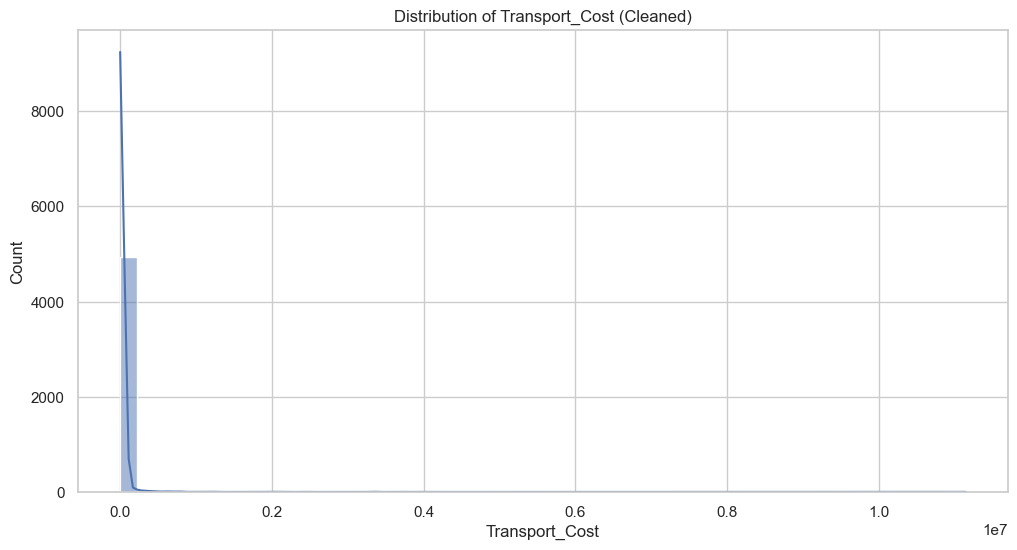

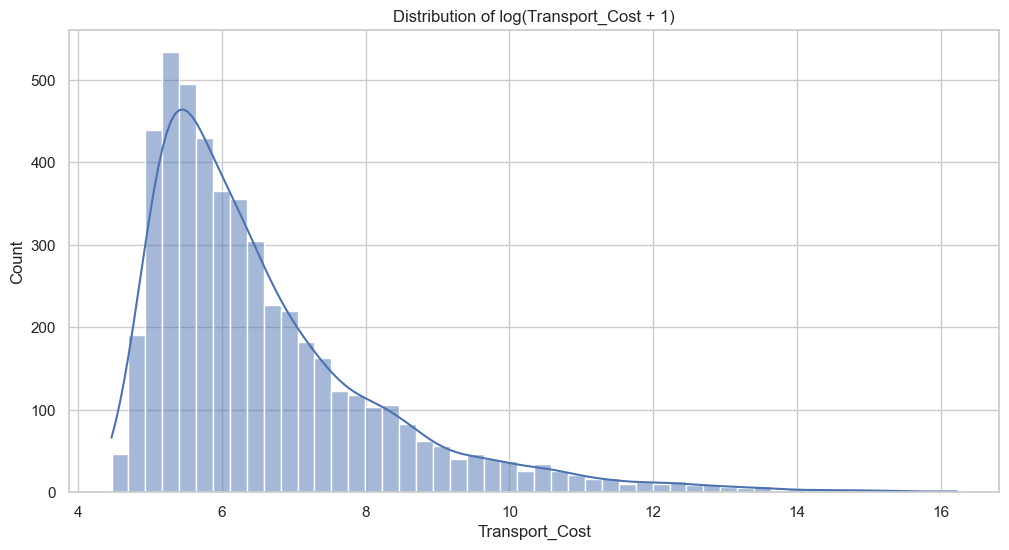

In [6]:
plt.figure(figsize=(12, 6))
sns.histplot(train_df['Transport_Cost'], bins=50, kde=True)
plt.title('Distribution of Transport_Cost (Cleaned)')
plt.show()

# It's skewed, so let's check the log transform too
plt.figure(figsize=(12, 6))
sns.histplot(np.log1p(train_df['Transport_Cost']), bins=50, kde=True)
plt.title('Distribution of log(Transport_Cost + 1)')
plt.show()

In [7]:
# Combine for a full report
combined_df = pd.concat([train_df.drop('Transport_Cost', axis=1), test_df], axis=0)

missing_data = combined_df.isnull().sum()
missing_percentage = (missing_data / len(combined_df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage (%)': missing_percentage
})

# Filter to show only columns with missing data
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values(by='Missing Percentage (%)', ascending=False)

print("--- Missing Value Report (Train + Test) ---")
print(missing_report)

--- Missing Value Report (Train + Test) ---
                      Missing Count  Missing Percentage (%)
Transport_Method               1194               21.709091
Equipment_Type                  655               11.909091
Rural_Hospital                  650               11.818182
Supplier_Reliability            642               11.672727
Equipment_Weight                512                9.309091
Equipment_Width                 499                9.072727
Equipment_Height                306                5.563636


In [8]:
# We need to apply this to the combined_df to keep train and test consistent
print("Original Hospital_Location examples:")
print(combined_df['Hospital_Location'].head())

# 1. Split Location into City and Country
# This regex handles both 'City, Country' and 'City Country' formats
combined_df['Hospital_City'] = combined_df['Hospital_Location'].str.split(r', | ').str[0]
combined_df['Hospital_Country'] = combined_df['Hospital_Location'].str.split(r', | ').str[-1]

print("\nSplit Location examples:")
print(combined_df[['Hospital_Location', 'Hospital_City', 'Hospital_Country']].head())


# 2. Calculate Shipping_Time
combined_df['Order_Placed_Date'] = pd.to_datetime(combined_df['Order_Placed_Date'])
combined_df['Delivery_Date'] = pd.to_datetime(combined_df['Delivery_Date'])

combined_df['Shipping_Time'] = (combined_df['Delivery_Date'] - combined_df['Order_Placed_Date']).dt.days

# Check for negative shipping times, just like you did
negative_shipping = combined_df[combined_df['Shipping_Time'] < 0]['Shipping_Time'].count()
print(f"\nFound {negative_shipping} instances of negative Shipping_Time.")

# Apply the absolute value fix
combined_df['Shipping_Time'] = combined_df['Shipping_Time'].abs()
print("FIX APPLIED: Replaced Shipping_Time with its absolute value.")

Original Hospital_Location examples:
0             APO AA 33776
1    South Kevin, VT 84493
2     Kevinshire, NE 31279
3             DPO AP 61572
4    Joshuamouth, AK 01550
Name: Hospital_Location, dtype: object

Split Location examples:
       Hospital_Location Hospital_City Hospital_Country
0           APO AA 33776           APO            33776
1  South Kevin, VT 84493         South            84493
2   Kevinshire, NE 31279    Kevinshire            31279
3           DPO AP 61572           DPO            61572
4  Joshuamouth, AK 01550   Joshuamouth            01550


C:\Users\Aksha\AppData\Local\Temp\ipykernel_12596\4067013994.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  combined_df['Order_Placed_Date'] = pd.to_datetime(combined_df['Order_Placed_Date'])
C:\Users\Aksha\AppData\Local\Temp\ipykernel_12596\4067013994.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  combined_df['Delivery_Date'] = pd.to_datetime(combined_df['Delivery_Date'])



Found 2170 instances of negative Shipping_Time.
FIX APPLIED: Replaced Shipping_Time with its absolute value.


C:\Users\Aksha\AppData\Local\Temp\ipykernel_12596\993515852.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_processed['Transport_Cost'] = train_df['Transport_Cost']


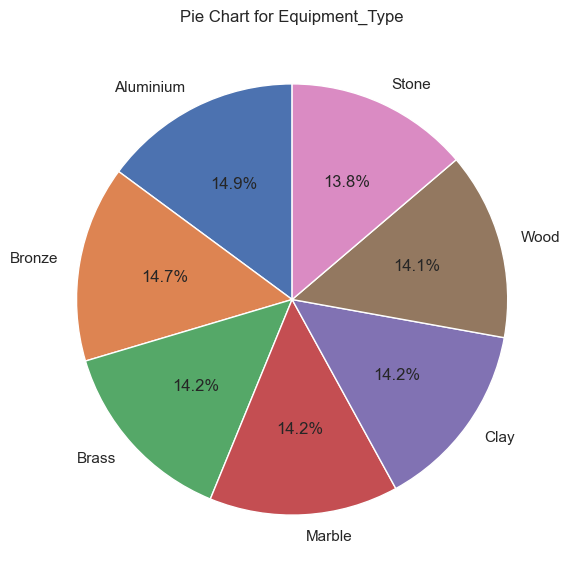

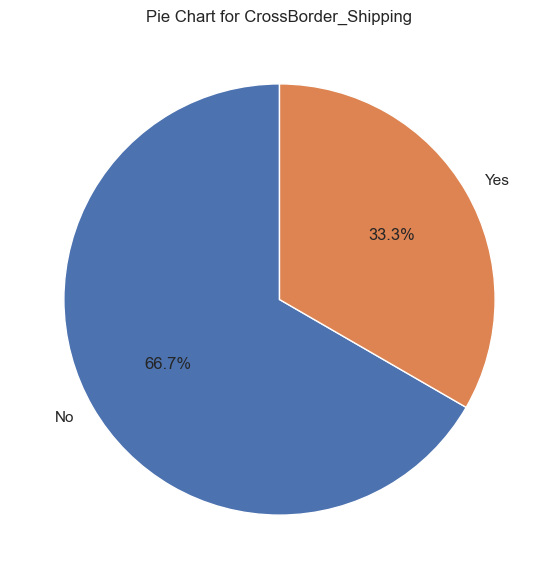

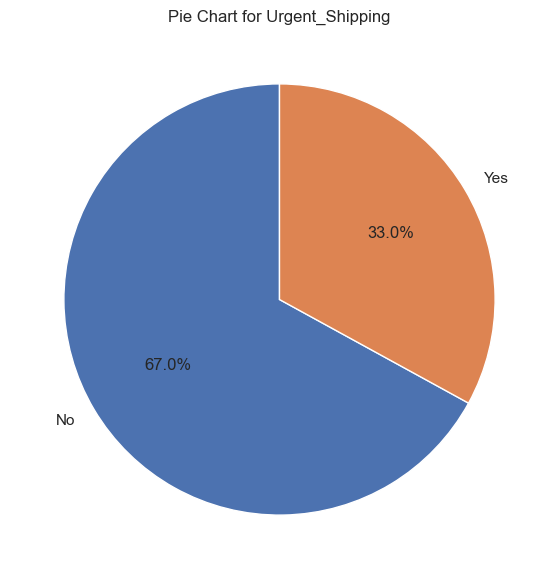

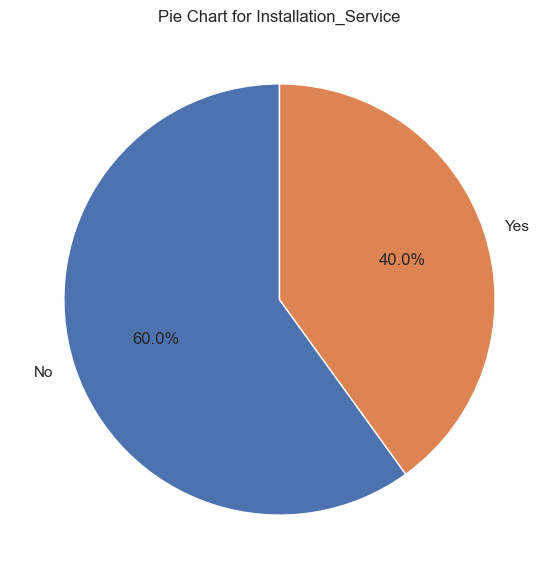

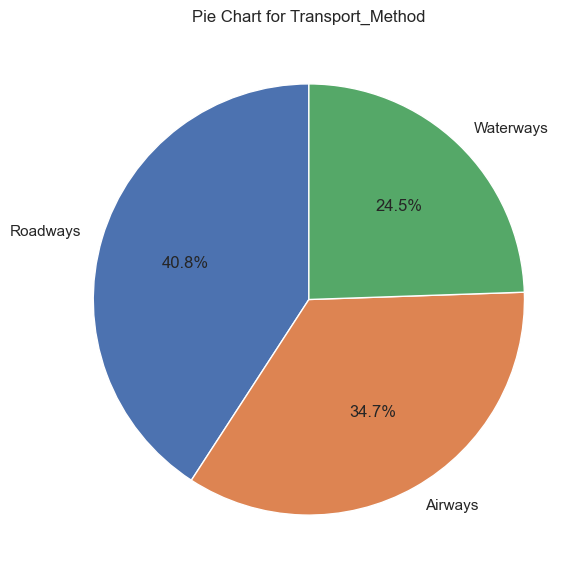

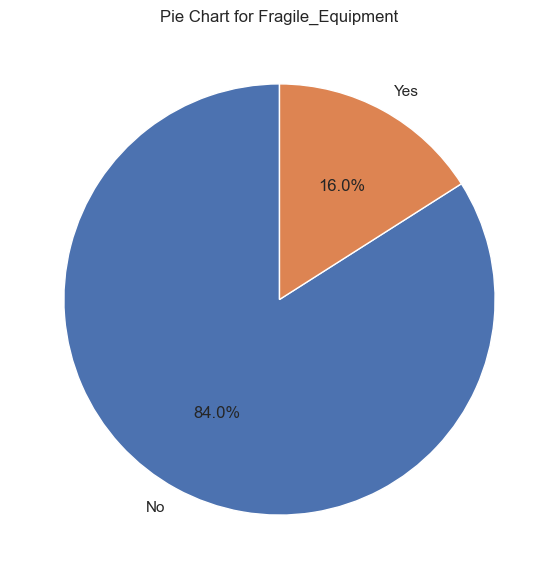

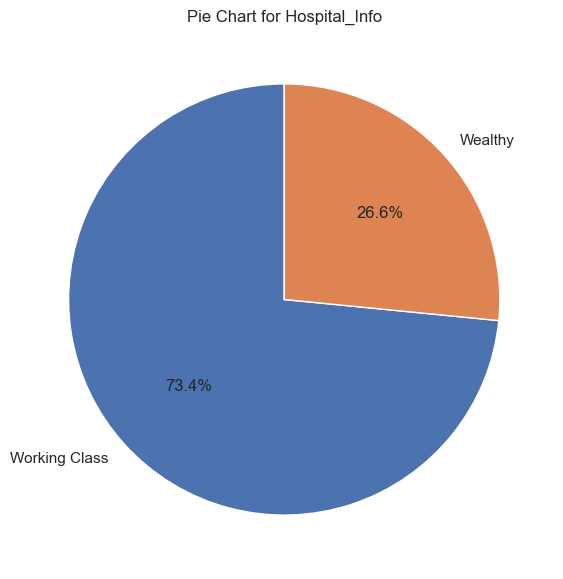

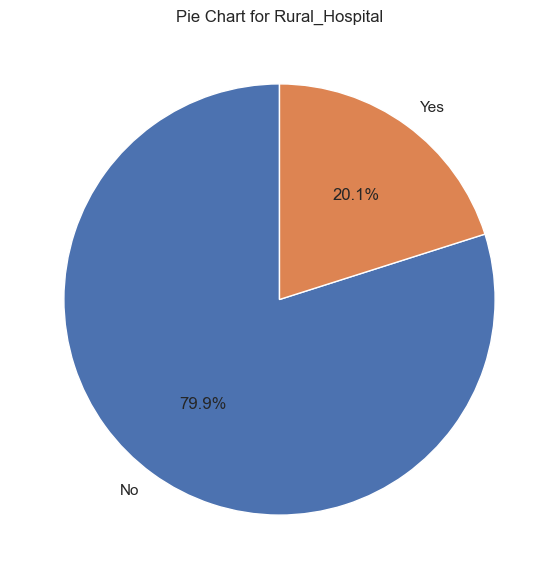

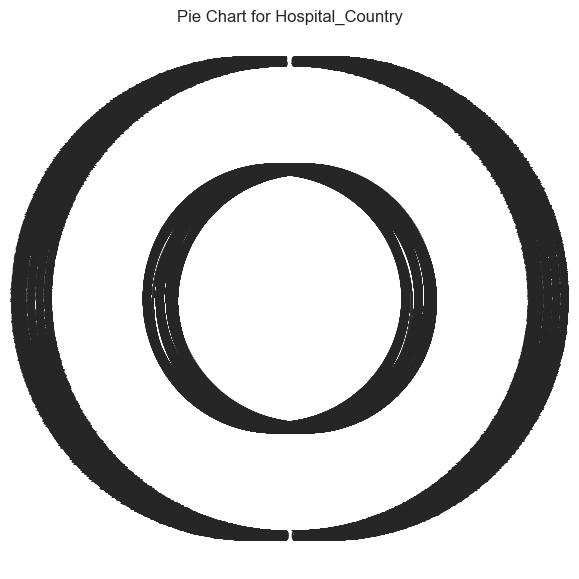

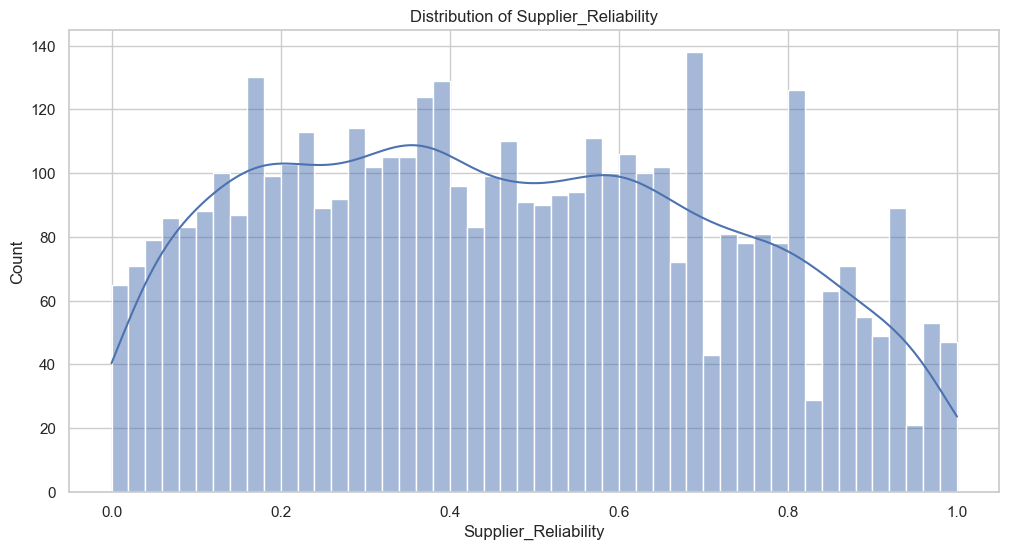

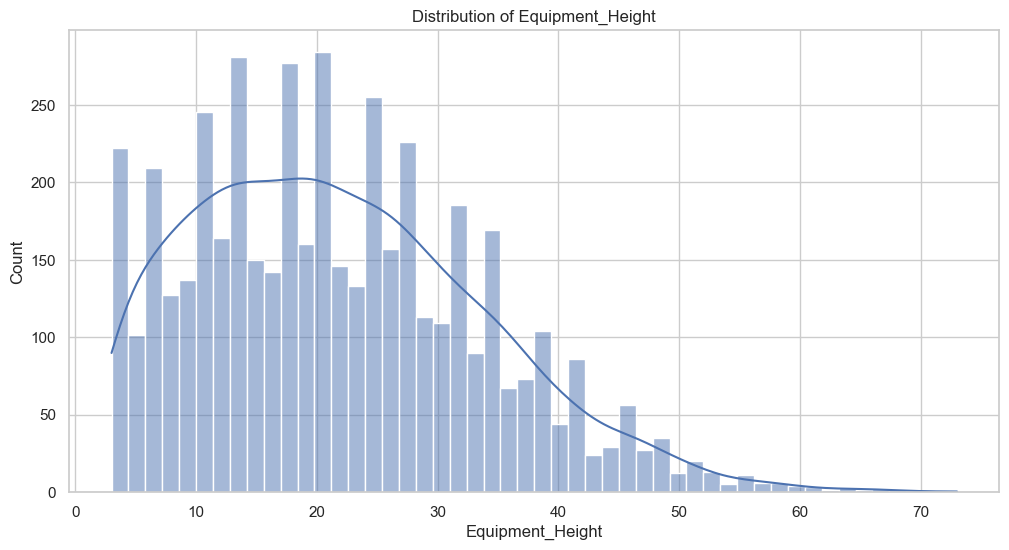

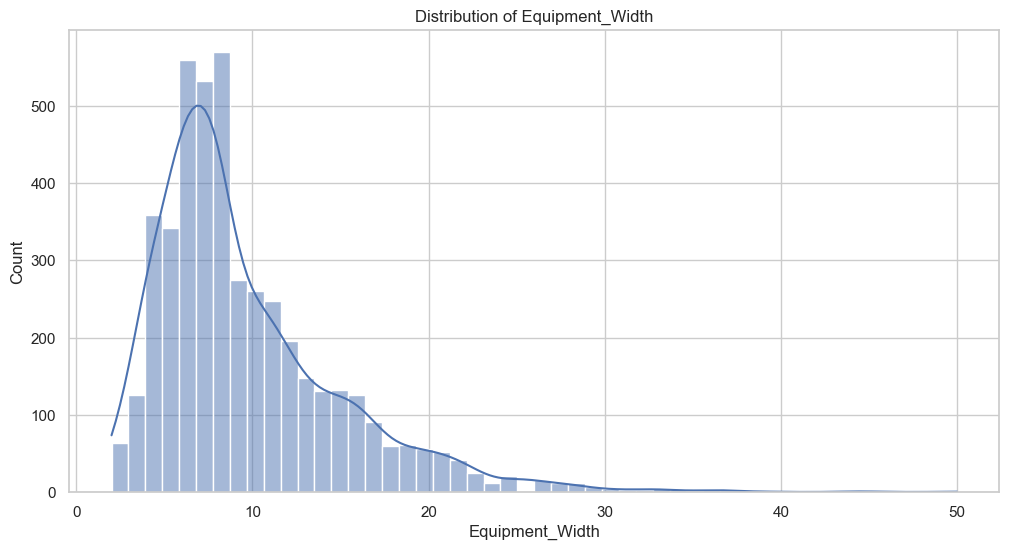

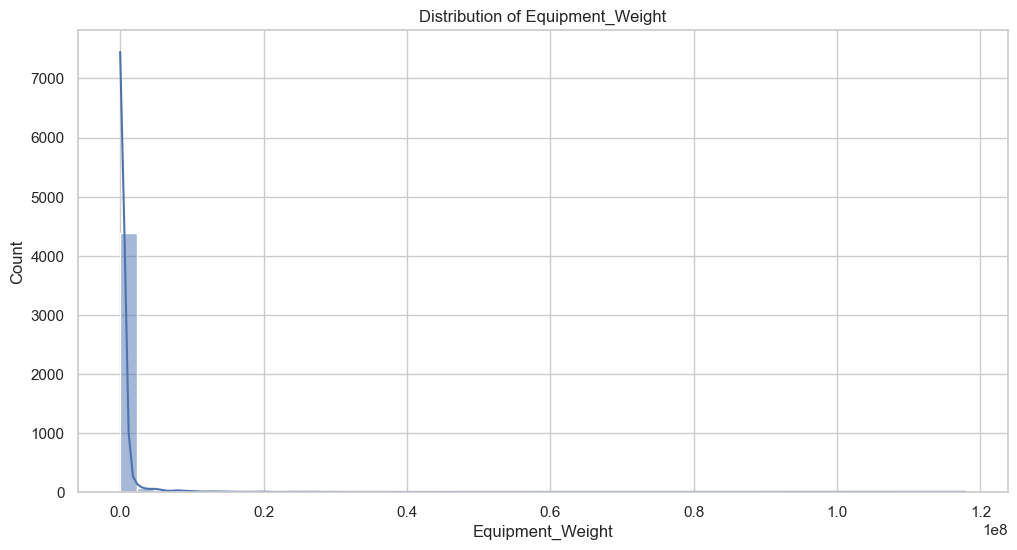

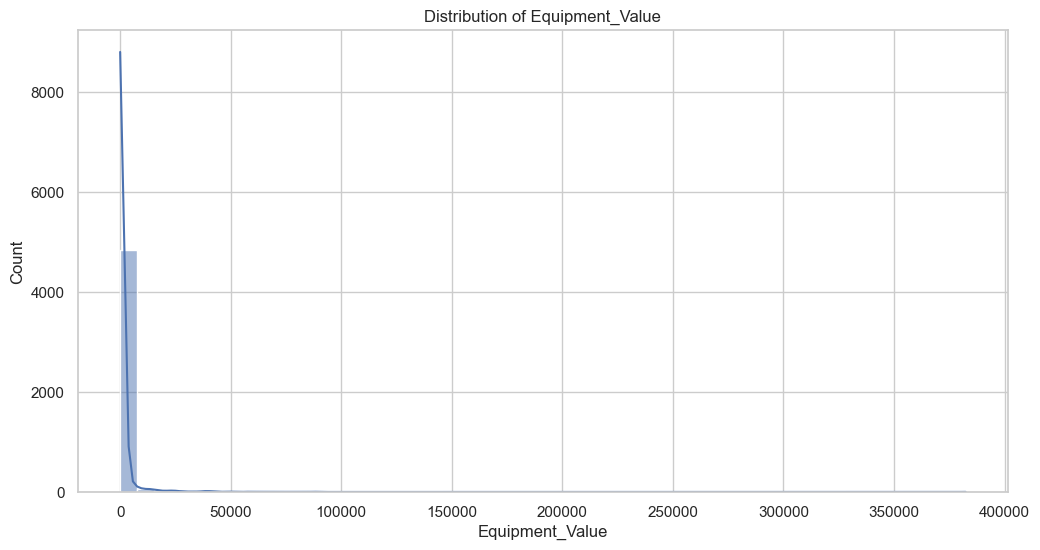

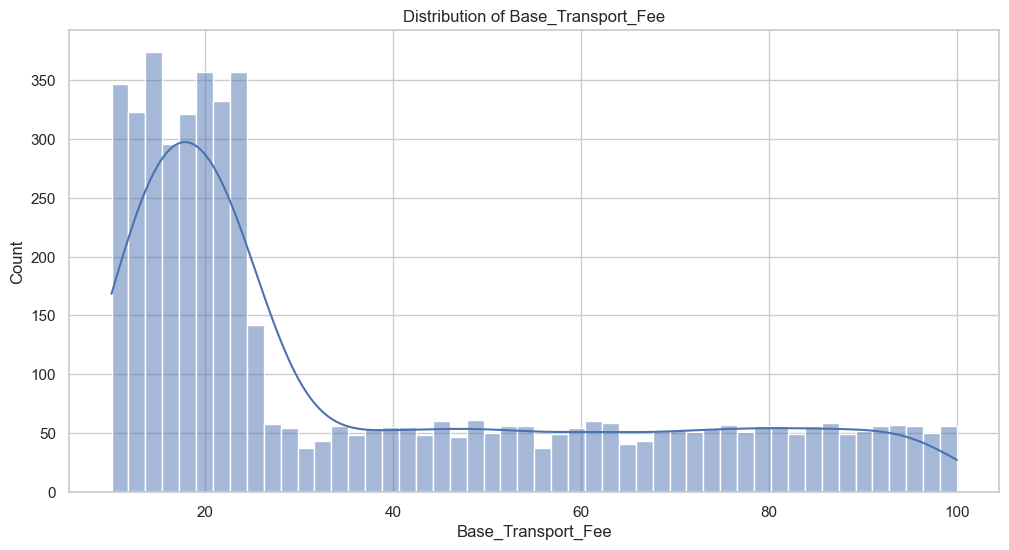

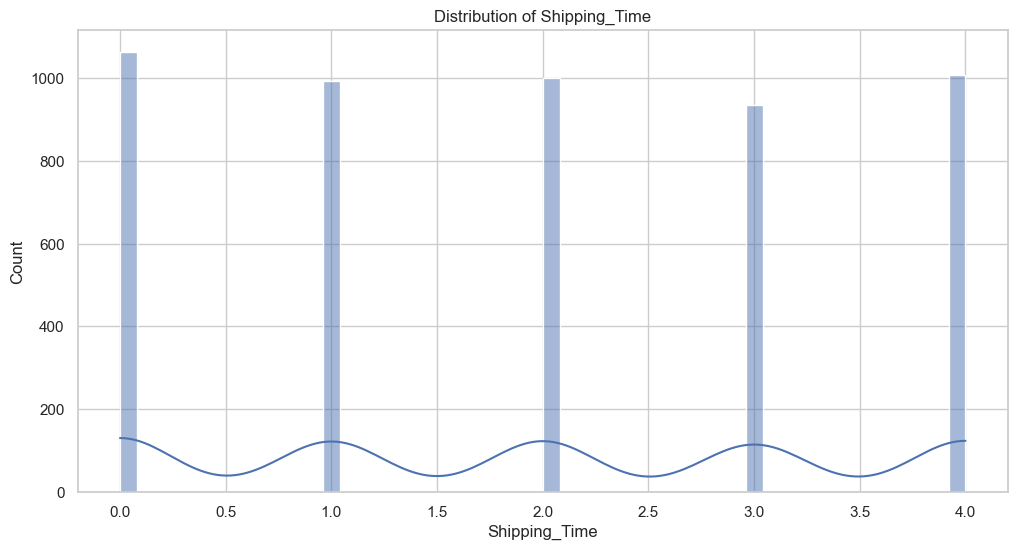

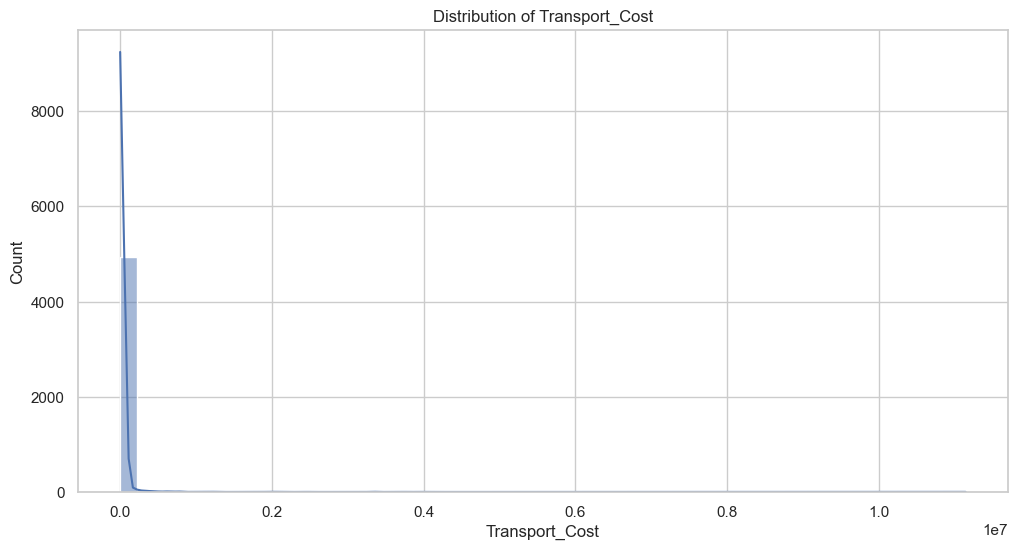

C:\Users\Aksha\AppData\Local\Temp\ipykernel_12596\993515852.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_processed['log_Transport_Cost'] = np.log1p(train_processed['Transport_Cost'])


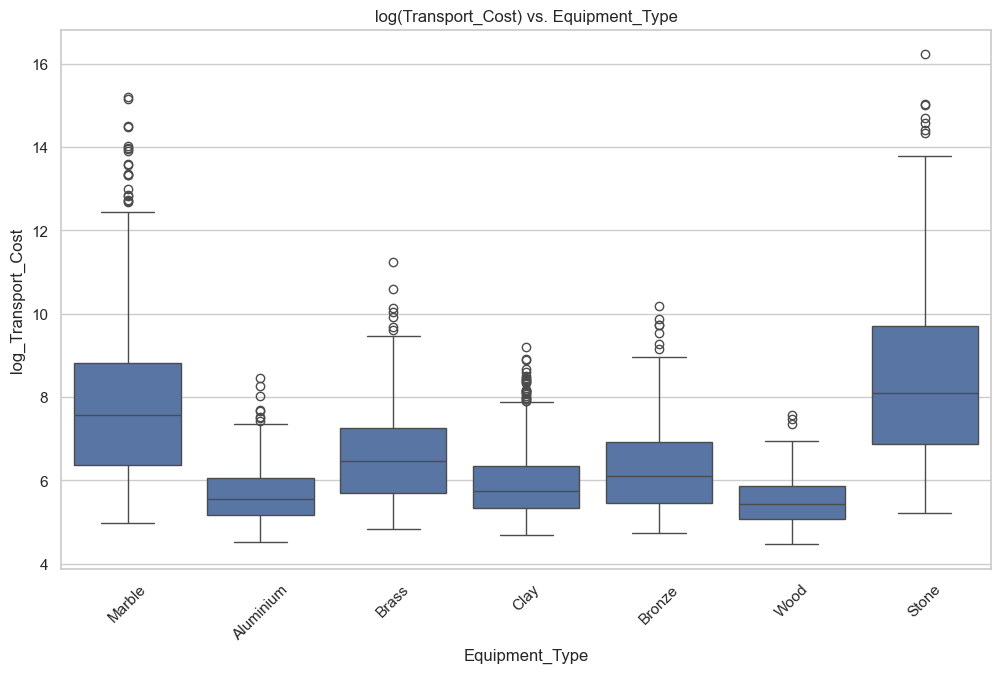

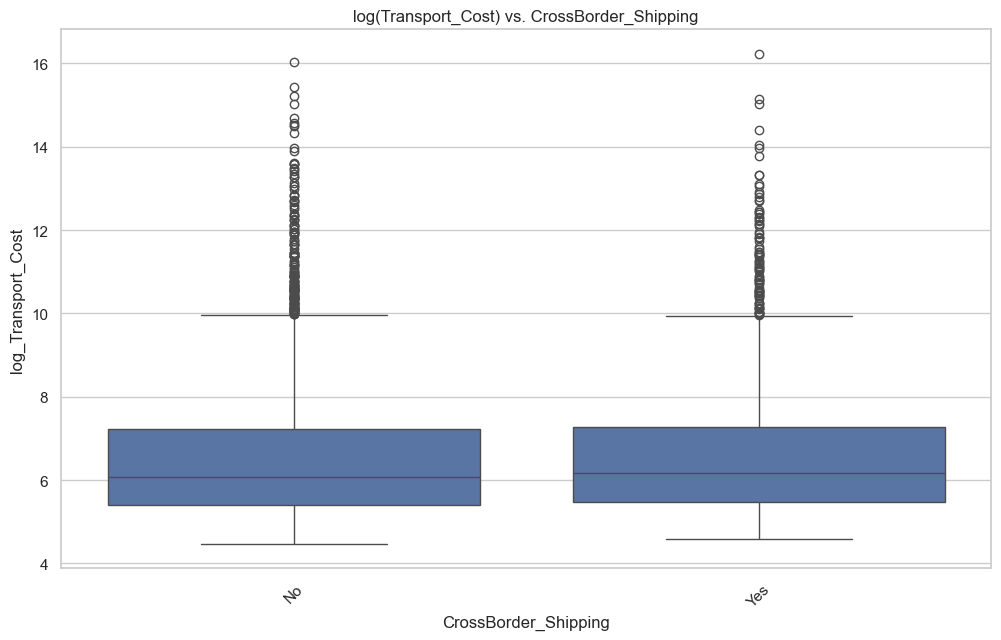

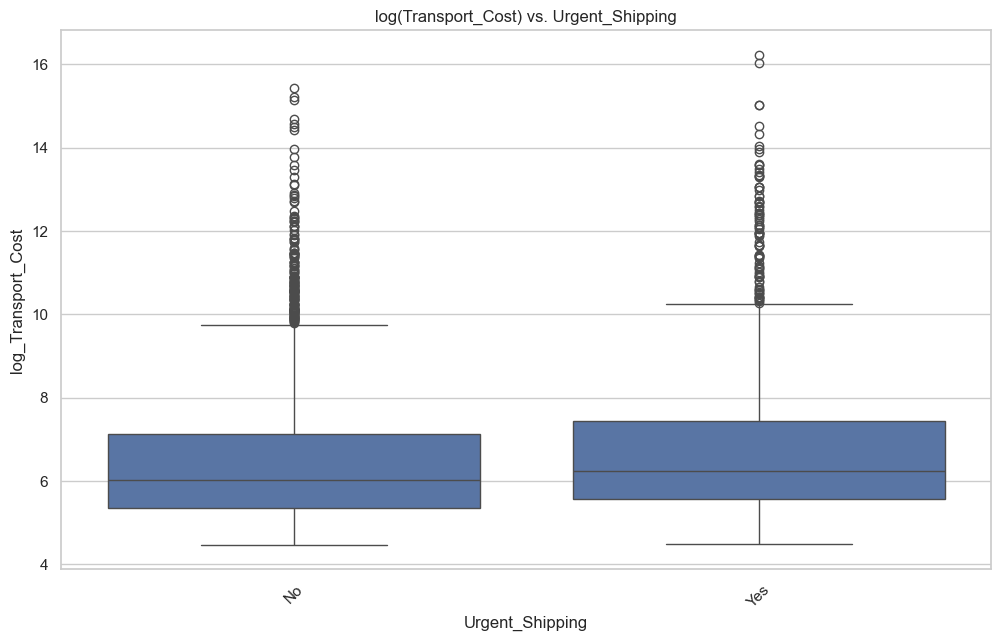

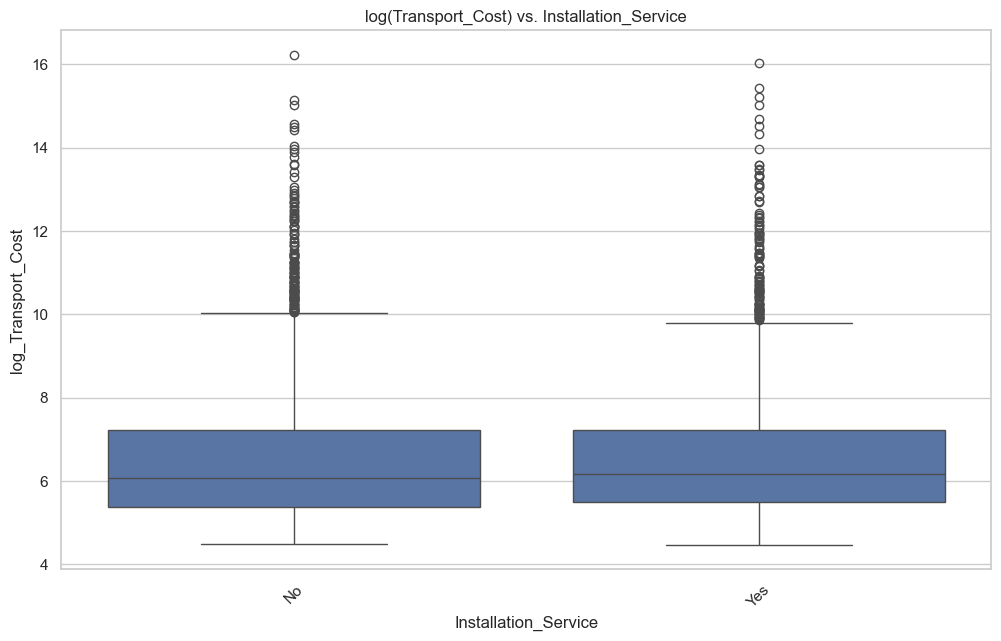

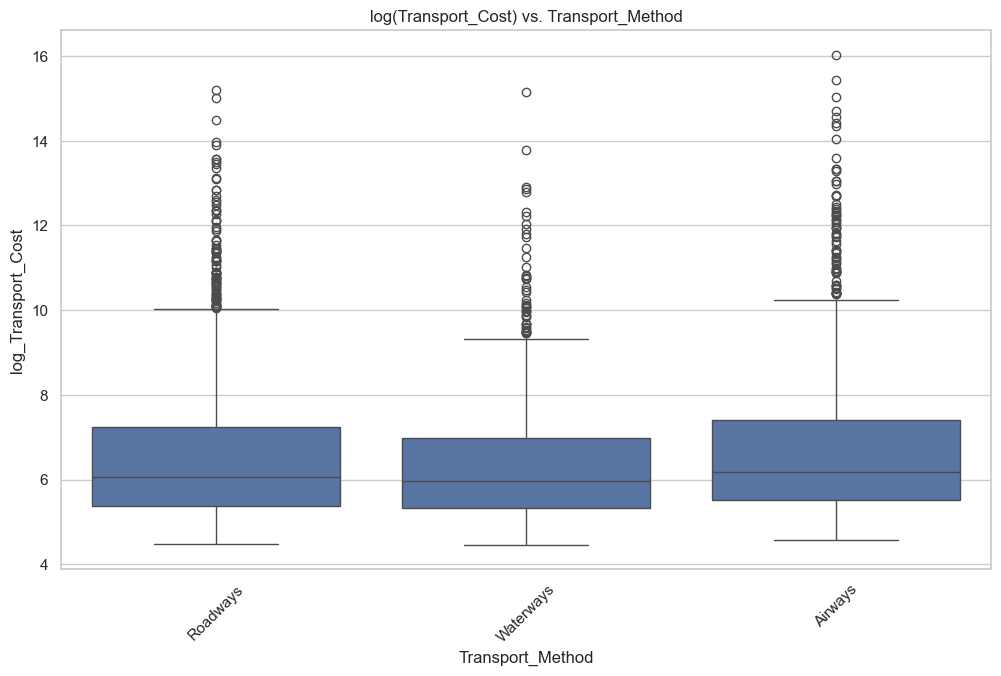

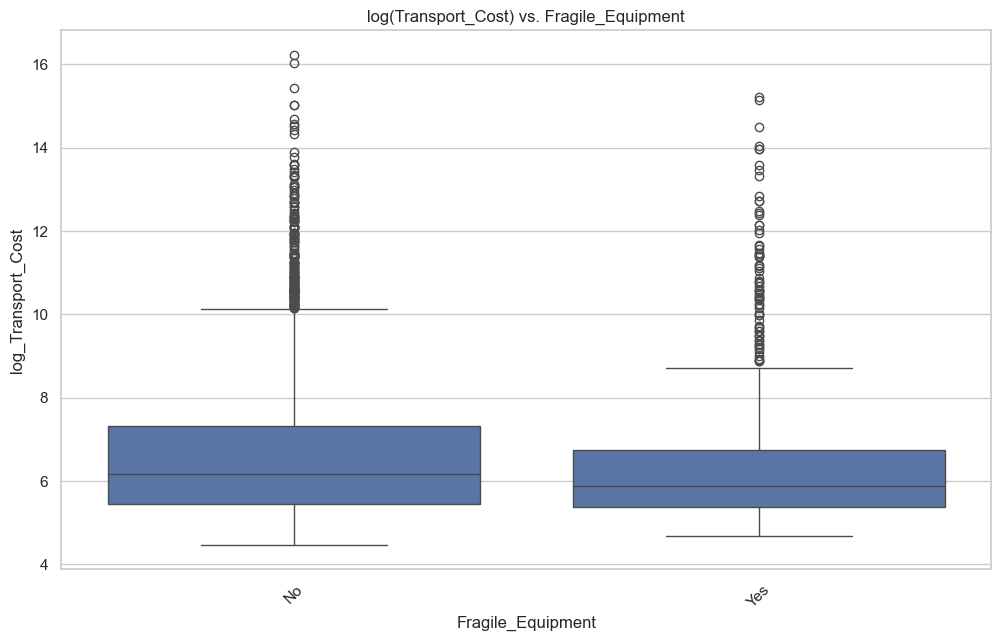

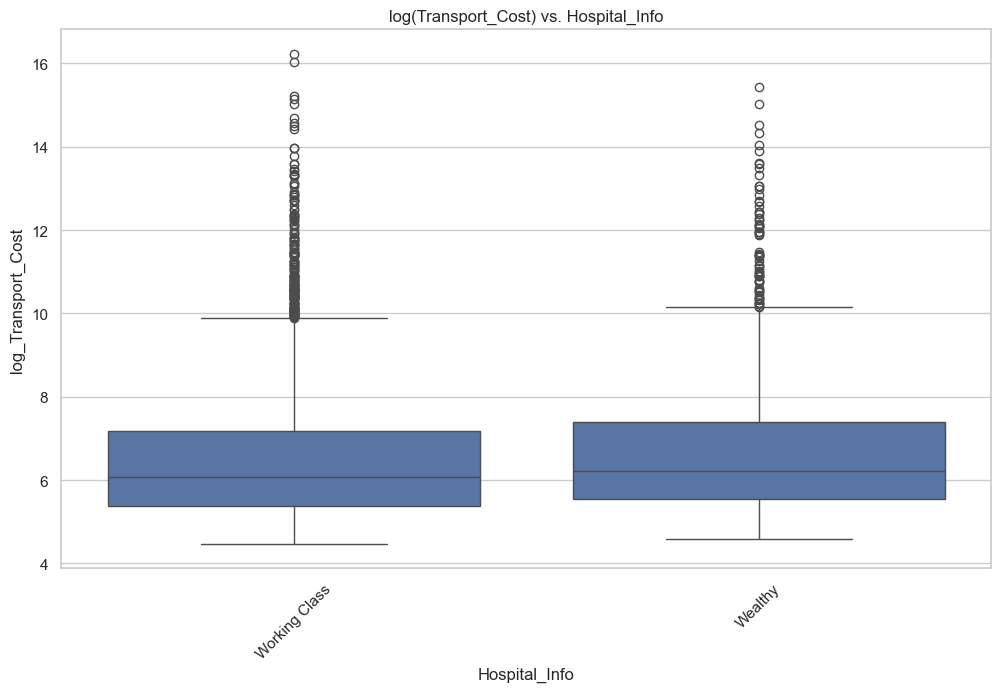

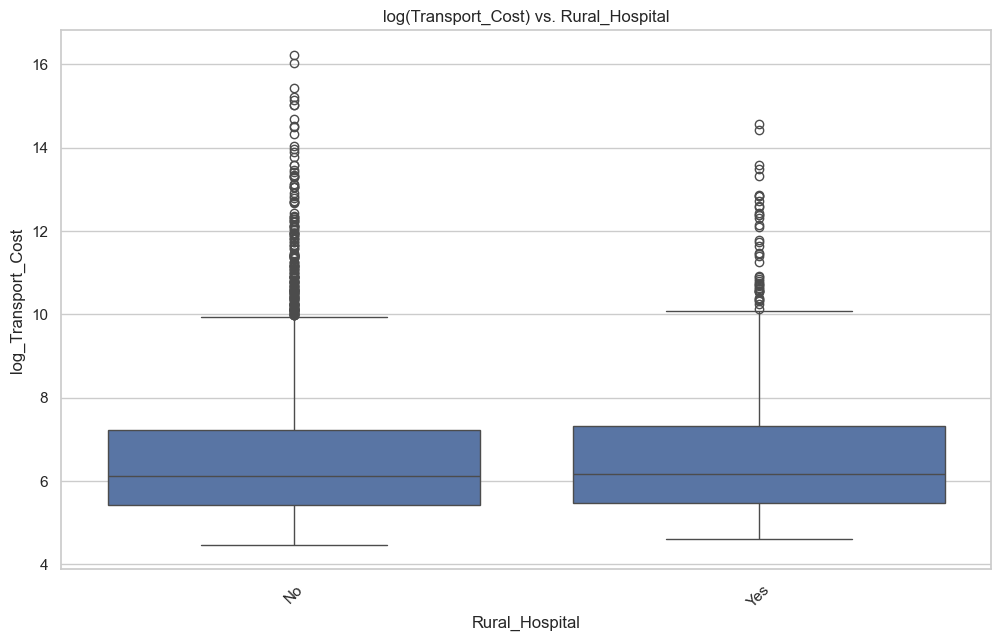

In [ ]:
# Separate back into train and test
train_processed = combined_df.iloc[:len(train_df)]
test_processed = combined_df.iloc[len(train_df):]

# Don't forget to add the target variable back to the processed train set
train_processed['Transport_Cost'] = train_df['Transport_Cost']


# Define categorical and numerical columns for plotting
# (Based on the .info() output)
cat_cols = ['Equipment_Type', 'CrossBorder_Shipping', 'Urgent_Shipping', 
            'Installation_Service', 'Transport_Method', 'Fragile_Equipment', 
            'Hospital_Info', 'Rural_Hospital', 'Hospital_Country']

num_cols = ['Supplier_Reliability', 'Equipment_Height', 'Equipment_Width', 
            'Equipment_Weight', 'Equipment_Value', 'Base_Transport_Fee', 
            'Shipping_Time', 'Transport_Cost']

# Plot pie charts for categorical features
for col in cat_cols:
    plt.figure(figsize=(10, 7))
    train_processed[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
    plt.title(f'Pie Chart for {col}')
    plt.ylabel('') # Hide the y-label
    plt.show()

# Plot distributions for numerical features
for col in num_cols:
    plt.figure(figsize=(12, 6))
    sns.histplot(train_processed[col], bins=50, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# Plot Bivariate (vs. Cost)
# We'll use the log of cost for clearer plots
train_processed['log_Transport_Cost'] = np.log1p(train_processed['Transport_Cost'])

for col in cat_cols:
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=train_processed, x=col, y='log_Transport_Cost')
    plt.title(f'log(Transport_Cost) vs. {col}')
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
plt.figure(figsize=(14, 10))
# We'll use the processed numerical columns + our new log_Transport_Cost
corr_cols = ['Supplier_Reliability', 'Equipment_Height', 'Equipment_Width', 
             'Equipment_Weight', 'Equipment_Value', 'Base_Transport_Fee', 
             'Shipping_Time', 'log_Transport_Cost']
             
corr_matrix = train_processed[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()